# Evaluating A/B Test

After we have collected enough samples for the A/B test, here we will evaluate the result using statistical testing.

In [ ]:
import numpy as np
import pandas as pd
import os

pd.options.display.max_columns = 999
pd.options.display.float_format = "{:.2f}".format

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

# # where is your data
# data_path = '/content/drive/My Drive/'

The following is the data for the News A/B Testing to increase the subscripition rate

In [ ]:
df = pd.read_csv('news_ab_test.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90251 entries, 0 to 90250
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           90251 non-null  object 
 1   group             90251 non-null  object 
 2   device            90251 non-null  object 
 3   gender            90251 non-null  object 
 4   time_spent        90251 non-null  float64
 5   session_duration  90251 non-null  float64
 6   page_views        90251 non-null  int64  
 7   conversion        90251 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 5.5+ MB


Data description:

* user_id: ID of the user
* group: the group assigned to each user (control/variant)
* device: device used by the user (desktop/mobile)
* time_spent: total time spent on the app during experiment
* page_views: total page viewed by user during experiment
* conversion: whether the user subscribe to the news (1) or not (0)

## Conversion Rate

First, we will evaluate if the conversion has increased with the new variant. To compare the proportion between two different samples, we can use the proportion z-test.

### Proportion Z Test


In [ ]:
pd.crosstab(df['group'], df['conversion'], normalize='index')

conversion,0,1
group,,
Control,0.90,0.10
Variant,0.85,0.15


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

Superiority testing

$H_0: variant \leq control$

$H_1: variant > control$

In [ ]:
# Proportion z-test
group_a = df[ df['group'] == 'Control']
group_b = df[ df['group'] == 'Variant']

conversion = [ group_b['conversion'].sum() , group_a['conversion'].sum() ]
sample = [ group_b.shape[0], group_a.shape[0] ]

z_stat, p_value = proportions_ztest(conversion, sample, alternative = 'larger')

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


In [ ]:
# contoh conversion rate variant lebih tinggi tapi tidak signifikan
z_stat, p_value = proportions_ztest([120, 110], [1000, 1000], alternative = 'larger')

print(f"p-value: {p_value:.4f}")

p-value: 0.2417


Cara membaca p-value

- kalau p-value < 0.05 --> ambil H_1
- kalau p-value >= 0.05 --> ambil H_0

## Session Duration

In [ ]:
#  Session Duration
session_a = group_a['session_duration']
session_b = group_b['session_duration']

session_a.head()

,session_duration
2,7.76
3,6.37
4,9.24
5,7.43
7,9.95


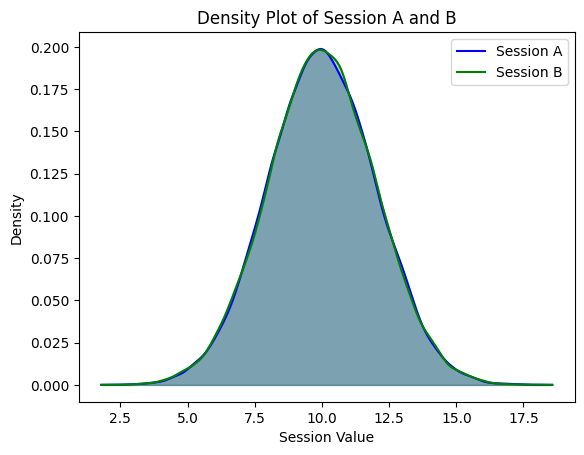

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Density estimates
density_a = gaussian_kde(session_a)
density_b = gaussian_kde(session_b)

x_vals = np.linspace(
    min(min(session_a), min(session_b)),
    max(max(session_a), max(session_b)),
    200
)

# Evaluate densities
y_a = density_a(x_vals)
y_b = density_b(x_vals)

# Plot
plt.plot(x_vals, y_a, label='Session A', color='blue')
plt.fill_between(x_vals, y_a, alpha=0.3, color='blue')

plt.plot(x_vals, y_b, label='Session B', color='green')
plt.fill_between(x_vals, y_b, alpha=0.3, color='green')

plt.xlabel('Session Value')
plt.ylabel('Density')
plt.title('Density Plot of Session A and B')
plt.legend()
plt.show()

### Normality Test


In [ ]:
from scipy import stats

In [ ]:
def ad_normal_test(x):
  # Perform the Anderson-Darling test
  result = stats.anderson(x, dist='norm')

  # Interpretation
  for cv, sig in zip(result.critical_values[2:], result.significance_level[2:]):
    if result.statistic < cv:
        print(f"Fail to reject normality at {sig}% significance level")
    else:
        print(f"Reject normality at {sig}% significance level")

Fail to reject at 5% --> data berdistribusi normal

In [ ]:
# normality test -- session duration group control
ad_normal_test(session_a)

Fail to reject normality at 5.0% significance level
Fail to reject normality at 2.5% significance level
Fail to reject normality at 1.0% significance level


In [ ]:
# normality test -- session duration group variant
ad_normal_test(session_b)

Fail to reject normality at 5.0% significance level
Fail to reject normality at 2.5% significance level
Fail to reject normality at 1.0% significance level


### Independent t-test

$H_0: session_{Variant} \leq session_{Control}$

$H_1: session_{Variant} > session_{Control}$

In [ ]:
# Perform independent t-test
t_stat, p_value = stats.ttest_ind(session_b, session_a, alternative = 'greater')

print(f"p-value: {p_value:.4f}")

p-value: 0.5987


In [ ]:
print(session_a.mean())
print(session_b.mean())

9.999789501556624
9.996453015055353


## Page Views

In [ ]:
# Evaluating page view
page_a = group_a['page_views']
page_b = group_b['page_views']

# Uji normalitas
print("Control")
ad_normal_test(page_a)

print("Variant")
ad_normal_test(page_b)

Control
Reject normality at 5.0% significance level
Reject normality at 2.5% significance level
Reject normality at 1.0% significance level
Variant
Reject normality at 5.0% significance level
Reject normality at 2.5% significance level
Reject normality at 1.0% significance level


In [ ]:
# Perform independent t-test
t_stat, p_value = stats.ttest_ind(page_b, page_a, alternative = 'greater')

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


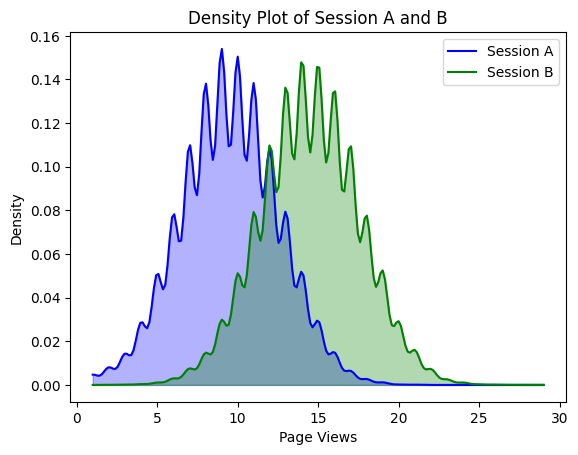

In [ ]:
# Density estimates
density_a = gaussian_kde(page_a)
density_b = gaussian_kde(page_b)

x_vals = np.linspace(
    min(min(page_a), min(page_b)),
    max(max(page_a), max(page_b)),
    200
)

# Evaluate densities
y_a = density_a(x_vals)
y_b = density_b(x_vals)

# Plot
plt.plot(x_vals, y_a, label='Session A', color='blue')
plt.fill_between(x_vals, y_a, alpha=0.3, color='blue')

plt.plot(x_vals, y_b, label='Session B', color='green')
plt.fill_between(x_vals, y_b, alpha=0.3, color='green')

plt.xlabel('Page Views')
plt.ylabel('Density')
plt.title('Density Plot of Session A and B')
plt.legend()
plt.show()

### Mann-Whitney Test

$H_0: View_{Variant} \leq View_{Control}$

$H_1: View_{Variant} > View_{Control}$

In [ ]:
# Perform the Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(page_b, page_a, alternative = 'greater')

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


In [ ]:
print(page_a.mean())
print(page_b.mean())

9.493773723113804
14.498761061946903


## Total Time Spent on Site

In [ ]:
# Evaluating page view